---
date: "2026-05-09"
date-modified: last-modified
format:
  html:
    toc: true
---

# The Bernoulli Distribution

The simplest [random variable](random-variables.ipynb) is one that can only take on two possible values: $0$ and $1$. This forms the foundation for many more complex probability distributions.

**Definition (Bernoulli Distribution):** A random variable $X$ follows a Bernoulli distribution if it takes the value $1$ with probability $p$ and the value $0$ with probability $1 - p$ (where $0 < p < 1$). 

We denote this relationship mathematically as:
$$X \sim \text{Bern}(p)$$ 
The "$\sim$" symbol is shorthand for "is distributed as".

::: {.callout-note title="Remark: Families of Distributions"}
There isn't just one single Bernoulli distribution. Instead, there is an entire *family* of them, uniquely identified by the parameter $p$. Saying "X is Bernoulli" is incomplete; you must specify the parameter, like $X \sim \text{Bern}(0.3)$, to fully define how the probabilities are distributed.
:::

## The Bernoulli Trial Story

We often use the analogy of a coin toss to explain Bernoulli variables, but this represents a much broader category of experiments.

::: {.callout-tip title="Story: The Bernoulli Trial"}
A **Bernoulli trial** is any random experiment that results in exactly one of two mutually exclusive outcomes: a "success" or a "failure". 

The Bernoulli random variable simply functions as an indicator of success for this trial: $X = 1$ means success, and $X = 0$ means failure. Consequently, the parameter $p$ is often referred to as the *success probability*.
:::

---

# The Binomial Distribution

Once we understand a single Bernoulli trial, it is natural to ask what happens when we perform multiple trials in a row.

::: {.callout-tip title="Story: The Binomial Distribution"}
Imagine we conduct $n$ independent Bernoulli trials, and every single trial has the exact same probability of success, $p$. If we define a random variable $X$ to represent the *total number of successes* across all $n$ trials, then $X$ follows a **Binomial distribution**.

We denote this as $X \sim \text{Bin}(n, p)$, where $n$ is a positive integer representing the number of trials, and $0 < p < 1$ is the success probability per trial.
:::

::: {.callout-note title="Intuition: Why use Stories?"}
Defining a distribution by its "story" (the physical experiment that generates it) rather than just a dry formula is a powerful technique in probability. It allows for quick pattern recognition. For instance, knowing the stories immediately reveals that a $\text{Bern}(p)$ distribution is exactly the same as a $\text{Bin}(1, p)$ distribution!
:::

## The Binomial Probability Mass Function (PMF)

Using the story above, we can systematically derive the mathematical formula (the PMF) for the Binomial distribution.

**Theorem (Binomial PMF):** If a random variable $X \sim \text{Bin}(n, p)$, its Probability Mass Function is given by:

$$P(X = k) = \binom{n}{k} p^k (1 - p)^{n - k}$$

for any integer $k \in \{0, 1, \dots, n\}$. For any other value of $k$, $P(X = k) = 0$.

**Proof:**
Consider an experiment of $n$ independent Bernoulli trials. We want to find the probability of getting exactly $k$ successes. 

1. The probability of observing one specific sequence of exactly $k$ successes and $n - k$ failures is $p^k(1-p)^{n-k}$, because the trials are independent.
2. However, there are many different ways to arrange $k$ successes among $n$ trials. The total number of valid sequences is given by the combination formula "n choose k", written as $\binom{n}{k}$.
3. Multiplying the number of valid sequences by the probability of each sequence gives the total probability: $\binom{n}{k} p^k (1 - p)^{n - k}$.

*(Note: This forms a valid PMF because all probabilities are non-negative, and by the Binomial Theorem from algebra, the sum of these probabilities across all possible values of $k$ perfectly equals $1$.)*

---

# Symmetries of the Binomial Distribution

The story of the Binomial distribution allows us to easily prove some highly useful symmetric properties.

## Swapping Successes and Failures

**Theorem:** Let $X \sim \text{Bin}(n, p)$. If we define $q = 1 - p$ (the probability of failure), then the number of failures, $n - X$, follows a Binomial distribution parameterized by $q$: 
$$n - X \sim \text{Bin}(n, q)$$

**Proof (Story Approach):**
By definition, $X$ counts the number of successes in $n$ independent Bernoulli trials. Therefore, $n - X$ logically counts the number of *failures* in those exact same trials. If we simply redefine what we call a "success" and a "failure", the structure of the experiment remains identical, but the success probability is now $q$. Thus, the failures follow a $\text{Bin}(n, q)$ distribution.

**Proof (Algebraic Approach):**
Let $Y = n - X$. We can evaluate the PMF of $Y$:
$$P(Y = k) = P(n - X = k) = P(X = n - k)$$
Applying the Binomial PMF formula for $X$:
$$P(X = n - k) = \binom{n}{n-k} p^{n-k} q^k$$
Since choosing $n-k$ items is combinatorially identical to choosing $k$ items ($\binom{n}{n-k} = \binom{n}{k}$), we can rewrite this as:
$$P(Y = k) = \binom{n}{k} q^k p^{n-k}$$
This is precisely the PMF for a $\text{Bin}(n, q)$ distribution. $\square$

## Perfect Symmetry at p = 0.5

**Corollary:** Let $X \sim \text{Bin}(n, p)$ where $p = 1/2$ and $n$ is an even number. The distribution of $X$ is perfectly symmetric around its center point $n/2$. Mathematically, for any non-negative integer $j$:
$$P(X = n/2 + j) = P(X = n/2 - j)$$

**Proof:**
From our previous theorem, we know $n - X \sim \text{Bin}(n, 1 - p)$. Since $p = 1/2$, it follows that $1 - p = 1/2$. Therefore, $X$ and $n - X$ share the exact same $\text{Bin}(n, 1/2)$ distribution, meaning $P(X = k) = P(n - X = k) = P(X = n - k)$ for any valid $k$. 

If we substitute $k = n/2 + j$ into this equality, we get:
$$P(X = n/2 + j) = P(X = n - (n/2 + j)) = P(X = n/2 - j)$$
This confirms the distribution is symmetric around the midpoint. $\square$

---

# Visualizing Binomial Distributions

To build intuition about how the parameters $n$ and $p$ shape the distribution, we can visualize the PMF. Notice how the distribution is perfectly symmetric when $p = 0.5$, but skews heavily to the left or right when $p$ approaches $0$ or $1$.

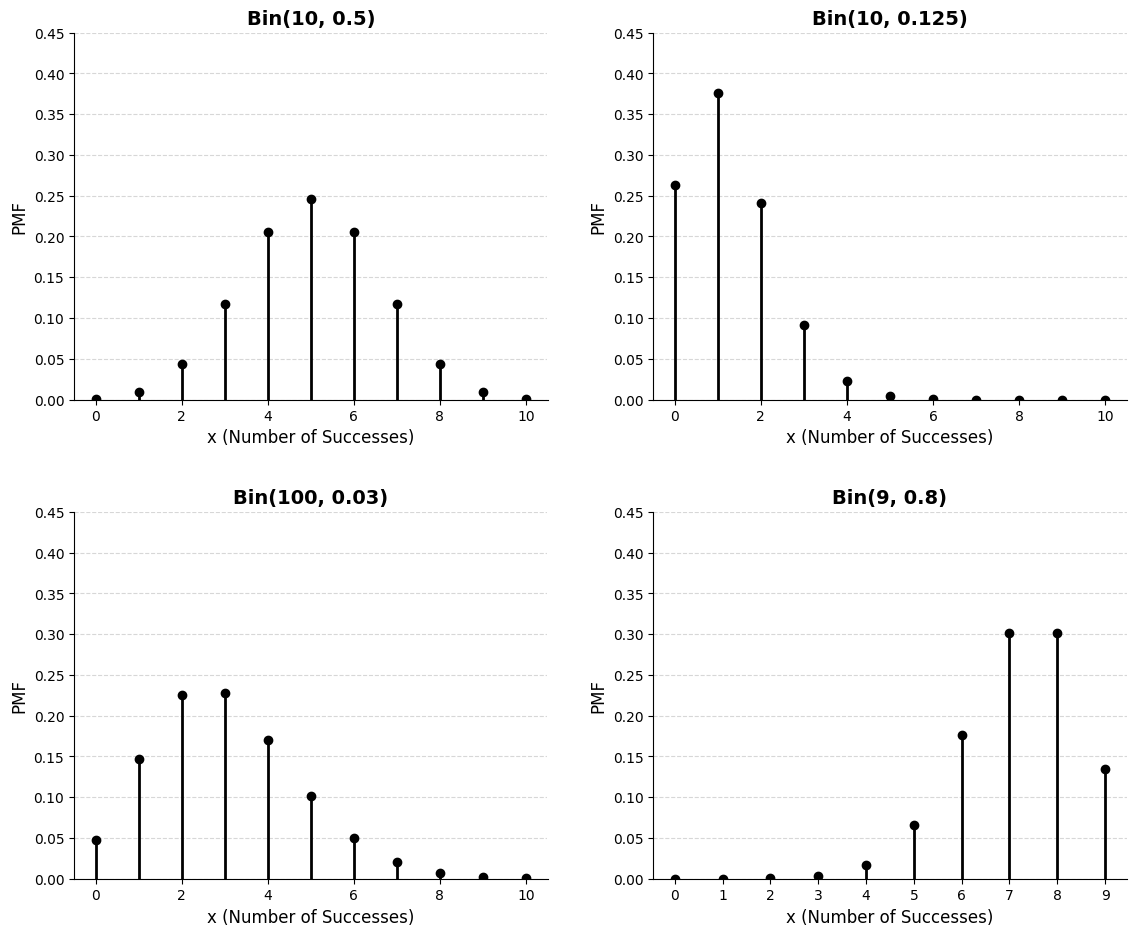

In [1]:
#| label: fig-binomial-pmfs
#| fig-cap: "Static visualizations of the Binomial PMF for different values of n and p. Notice the symmetry for p=0.5, and the skewness for other probabilities."

import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import binom

# Define parameter sets to visualize
params = [
    (10, 0.5),   # Symmetric, small n
    (10, 0.125), # Right-skewed (low success prob)
    (100, 0.03), # Right-skewed, large n (zoomed in view)
    (9, 0.8)     # Left-skewed (high success prob)
]

fig, axs = plt.subplots(2, 2, figsize=(12, 10))
axs = axs.flatten()

for i, (n, p) in enumerate(params):
    # For large n, we only plot the relevant support range to match the book's intuition
    x_max = 10 if n == 100 else n
    x = np.arange(0, x_max + 1)
    
    # Calculate PMF
    pmf_values = binom.pmf(x, n, p)
    
    # Plot stem chart
    axs[i].vlines(x, 0, pmf_values, color='black', lw=2)
    axs[i].plot(x, pmf_values, 'o', color='black', markersize=6)
    
    # Formatting
    axs[i].set_title(f'Bin({n}, {p})', fontsize=14, fontweight='bold')
    axs[i].set_xlabel('x (Number of Successes)', fontsize=12)
    axs[i].set_ylabel('PMF', fontsize=12)
    axs[i].set_ylim(0, 0.45)
    axs[i].set_xticks(np.arange(0, x_max + 1, max(1, x_max // 5)))
    axs[i].grid(axis='y', linestyle='--', alpha=0.5)
    axs[i].spines['top'].set_visible(False)
    axs[i].spines['right'].set_visible(False)

plt.tight_layout(pad=3.0)
plt.show()